# **Skin Diseases Recognition** — Version Corrigée
> ✅ Corrections appliquées : EarlyStopping, Dropout augmenté, BatchNormalization, ReduceLROnPlateau, Fine-tuning dégelé

## Import and Install Requirements

In [1]:
!pip install split-folders tqdm

In [ ]:
import os
import numpy as np
from google.colab import files
import splitfolders 
import matplotlib
import matplotlib.pyplot as plt
import itertools
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau  # ✅ AJOUT
import keras
from keras.preprocessing import image
import sklearn
from sklearn.metrics import confusion_matrix

In [3]:
!python --version
print('Tensorflow {}'.format(tf.__version__))
print('Numpy {}'.format(np.__version__))
print('Matplotlib {}'.format(matplotlib.__version__))
print('Splitfolder {}'.format(splitfolders.__version__))
print('Keras {}'.format(keras.__version__))
print('Scikit-learn {}'.format(sklearn.__version__))

Python 3.12.13
Tensorflow 2.20.0
Numpy 2.0.2
Matplotlib 3.10.0
Splitfolder 0.6.1
Keras 3.13.2
Scikit-learn 1.6.1


## Import and Split Data

Import data from google drive :

### 📌 Comment obtenir les IDs de sous-dossiers ?
1. Ouvre chaque sous-dossier dans Google Drive
2. Copie l'ID depuis l'URL : `https://drive.google.com/drive/folders/**ID_ICI**`
3. Remplace les valeurs `1FOLDER_ID_xxx` dans la cellule suivante

> **Pourquoi ?** `gdown` ne peut télécharger que 50 fichiers max par dossier. En téléchargeant chaque sous-dossier séparément, on contourne cette limite.

In [4]:
# ✅ Téléchargement via l'API Google Drive officielle (pas de limite de fichiers)
import os
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
from google.colab import auth
import io

# 🔐 Authentification Google (une fenêtre popup va s'ouvrir)
auth.authenticate_user()
drive_service = build('drive', 'v3')

def download_folder(service, folder_id, dest_path):
    """Télécharge récursivement tous les fichiers d'un dossier Google Drive."""
    os.makedirs(dest_path, exist_ok=True)
    page_token = None
    while True:
        response = service.files().list(
            q=f"'{folder_id}' in parents and trashed=false",
            fields='nextPageToken, files(id, name, mimeType)',
            pageToken=page_token,
            pageSize=1000
        ).execute()
        for f in response.get('files', []):
            fpath = os.path.join(dest_path, f['name'])
            if f['mimeType'] == 'application/vnd.google-apps.folder':
                download_folder(service, f['id'], fpath)
            else:
                request = service.files().get_media(fileId=f['id'])
                with io.FileIO(fpath, 'wb') as fh:
                    downloader = MediaIoBaseDownload(fh, request)
                    done = False
                    while not done:
                        _, done = downloader.next_chunk()
        page_token = response.get('nextPageToken')
        if not page_token:
            break

subfolders = {
    'Atopic dermatitis': '1OZqVOj5eNPEQCOIKg4npkDH8nhrEQxsP',
    'Cradle cap':        '18z-vqPgIl_IYQv80tTxdUta1A4Xk-Npt',
    'Diaper rash':       '1dVTVatKwzgXrXiZuFX-H6-r4m-do0miE',
    'Drool rash':        '1sPj6BIYuWr03xRyYHj3ViLVBlgy-24zp',
    'Hemangioma':        '1Pf4JjN_AJmrfg1QngSvufwMXuLW5LxC8',
    'HFMD':              '1-k0KYqLa6_C7k0AUdVBTnsUW41D4eyNr',
    'Impetigo':          '1mHQzbe_Fqf1BjsaeWEEWJx5PyXXDdILq',
    'Miliaria':          '1BEpG5SRmYat7m4mq22dSNlP6cpM9Tlv3',
    'Pityriasis':        '1FC_MhCLgZKyLCc5By8GF5exo9-gMUzg3',
    'Rubeola':           '1-3YztN-7yxrLTceGxA7KnWFzMnm7-WB3',
    'Varicella':         '1RXCBnk1XbP4LHba4_JLHwKjiFkbsqh6m',
}

base_path = '/content/Skin Diseases'

for name, fid in subfolders.items():
    dest = os.path.join(base_path, name)
    print(f'📥 Téléchargement : {name} ...')
    download_folder(drive_service, fid, dest)
    count = len(os.listdir(dest))
    print(f'✅ {name} : {count} images\n')


📥 Téléchargement : Atopic dermatitis ...
✅ Atopic dermatitis : 108 images

📥 Téléchargement : Cradle cap ...
✅ Cradle cap : 85 images

📥 Téléchargement : Diaper rash ...
✅ Diaper rash : 83 images

📥 Téléchargement : Drool rash ...
✅ Drool rash : 65 images

📥 Téléchargement : Hemangioma ...
✅ Hemangioma : 93 images

📥 Téléchargement : HFMD ...
✅ HFMD : 75 images

📥 Téléchargement : Impetigo ...
✅ Impetigo : 117 images

📥 Téléchargement : Miliaria ...
✅ Miliaria : 100 images

📥 Téléchargement : Pityriasis ...
✅ Pityriasis : 117 images

📥 Téléchargement : Rubeola ...
✅ Rubeola : 66 images

📥 Téléchargement : Varicella ...
✅ Varicella : 70 images



In [5]:
import os

base_path = "/content/Skin Diseases"
categories = [
    'Atopic dermatitis', 'Cradle cap', 'Diaper rash', 'Drool rash',
    'Hemangioma', 'HFMD', 'Impetigo', 'Miliaria', 'Pityriasis', 'Rubeola', 'Varicella'
]

for cat in categories:
    path = os.path.join(base_path, cat)
    count = len(os.listdir(path)) if os.path.exists(path) else "❌ NON TROUVÉ"
    print(f"{cat}: {count}")

Atopic dermatitis: 108
Cradle cap: 85
Diaper rash: 83
Drool rash: 65
Hemangioma: 93
HFMD: 75
Impetigo: 117
Miliaria: 100
Pityriasis: 117
Rubeola: 66
Varicella: 70


Total images in each diseases:

In [6]:
print('Atopic dermatitis: {}'.format(len(os.listdir('/content/Skin Diseases/Atopic dermatitis'))))
print('Cradle cap: {}'.format(len(os.listdir('/content/Skin Diseases/Cradle cap'))))
print('Diaper rash: {}'.format(len(os.listdir('/content/Skin Diseases/Diaper rash'))))
print('Drool Rush: {}'.format(len(os.listdir('/content/Skin Diseases/Drool rash'))))
print('HFMD: {}'.format(len(os.listdir('/content/Skin Diseases/HFMD'))))
print('Hemangioma: {}'.format(len(os.listdir('/content/Skin Diseases/Hemangioma'))))
print('Impetigo: {}'.format(len(os.listdir('/content/Skin Diseases/Impetigo'))))
print('Miliraia: {}'.format(len(os.listdir('/content/Skin Diseases/Miliaria'))))
print('Pityriasis: {}'.format(len(os.listdir('/content/Skin Diseases/Pityriasis'))))
print('Rubeola: {}'.format(len(os.listdir('/content/Skin Diseases/Rubeola'))))
print('Varicella: {}'.format(len(os.listdir('/content/Skin Diseases/Varicella'))))

Atopic dermatitis: 108
Cradle cap: 85
Diaper rash: 83
Drool Rush: 65
HFMD: 75
Hemangioma: 93
Impetigo: 117
Miliraia: 100
Pityriasis: 117
Rubeola: 66
Varicella: 70


Split data into training data (80%), validation data (10%) and testing data (10%) :

In [7]:
# ✅ Chemin corrigé
!mkdir -p skin_dataset

splitfolders.ratio(
    "/content/Skin Diseases",
    output="skin_dataset",
    seed=42,
    ratio=(.8, .1, .1),
    group_prefix=None
)

Copying files: 979 files [00:00, 5850.86 files/s]


Some sample images on training data :

Found 780 files belonging to 11 classes.


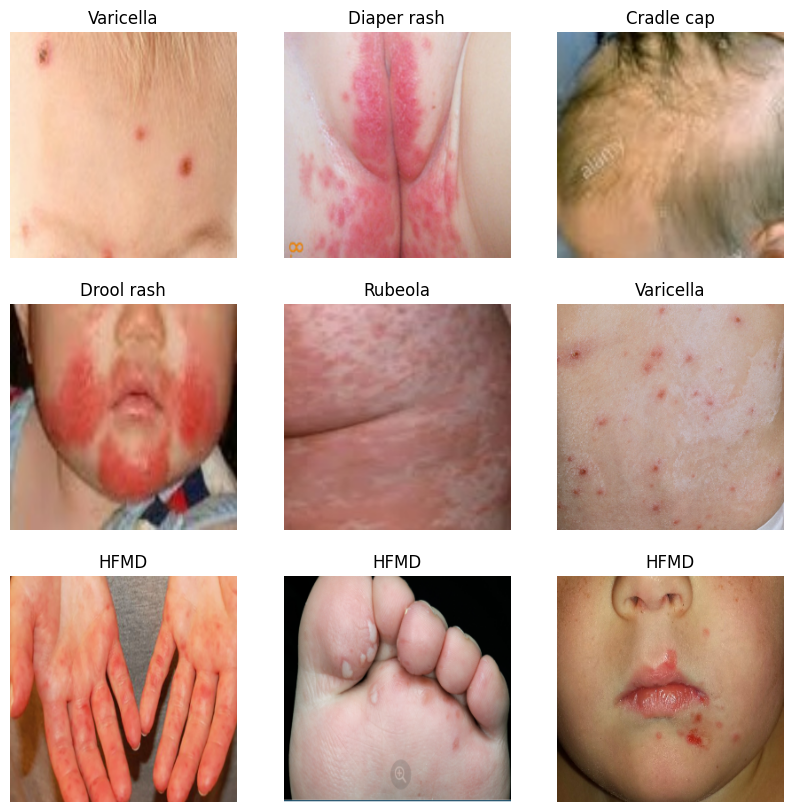

In [8]:
train_dataset = image_dataset_from_directory('/content/skin_dataset/train', shuffle=True)

class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

## MobileNet Model for Transfer Learning

In [9]:
mobile = tf.keras.applications.mobilenet.MobileNet(input_tensor = tf.keras.Input(shape=(224,224,3)))

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### ✅ Architecture corrigée
**Changements :**
- Dropout augmenté : `0.1` → `0.4` puis `0.3`
- Dense réduit : `1024` → `512` (évite l'overfitting)
- `BatchNormalization` ajoutée pour stabiliser l'apprentissage
- Dégel des 30 dernières couches pour le fine-tuning

In [13]:
x = mobile.layers[-6].output
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# ✅ CORRECTION 1 : Dropout augmenté de 0.1 → 0.4
x = tf.keras.layers.Dropout(0.4)(x)

# ✅ CORRECTION 2 : Dense réduit de 1024 → 512
x = tf.keras.layers.Dense(512, activation='relu')(x)

# ✅ CORRECTION 3 : BatchNormalization ajoutée
x = tf.keras.layers.BatchNormalization()(x)

# ✅ CORRECTION 4 : Dropout intermédiaire ajouté
x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Dense(128, activation='relu')(x)
output = tf.keras.layers.Dense(11, activation='softmax')(x)

model = Model(inputs=mobile.input, outputs=output)

# ✅ CORRECTION 5 : Dégel des 30 dernières couches (fine-tuning)
for layer in model.layers[:-30]:
    layer.trainable = False
for layer in model.layers[-30:]:
    layer.trainable = True

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,822,795 (14.58 MB)

 Trainable params: 2,718,731 (10.37 MB)

 Non-trainable params: 1,104,064 (4.21 MB)

## Image Data Generator

In [ ]:
train_dir = '/content/skin_dataset/train'
validation_dir = '/content/skin_dataset/val'

train_datagen = ImageDataGenerator(rescale=1/255.0,    # Nettoyage des pixels (Normalisation)
                                   rotation_range=40,       # Suppression du biais de l'angle
                                   width_shift_range=0.2,  # Suppression du biais de position
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.4,
                                   horizontal_flip=True,
                                   fill_mode='nearest')   # Nettoyage des zones vides après transformation

train_generator = train_datagen.flow_from_directory(train_dir,
                                                    target_size=(224,224),# Nettoyage de la taille 
                                                    batch_size=20,
                                                    class_mode = 'categorical')

test_datagen = ImageDataGenerator(rescale=1/255.0)

validation_generator = test_datagen.flow_from_directory(validation_dir,
                                                        target_size=(224,224),
                                                        batch_size=20,
                                                        class_mode = 'categorical')

Found 780 images belonging to 11 classes.
Found 93 images belonging to 11 classes.


## Training Model

### ✅ Callbacks ajoutés
- **EarlyStopping** : arrête si la val_loss ne s'améliore pas pendant 10 epochs
- **ModelCheckpoint** : sauvegarde automatiquement le meilleur modèle
- **ReduceLROnPlateau** : réduit le learning rate si stagnation

In [15]:
# ✅ CORRECTION 6 : Callbacks pour éviter l'overfitting
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

model.compile(
    optimizer=Adam(learning_rate=0.00002),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ✅ CORRECTION 7 : Ajout des callbacks au model.fit
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    callbacks=callbacks  # ← le modèle s'arrêtera automatiquement si nécessaire
)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.0832 - loss: 3.1929
Epoch 1: val_accuracy improved from None to 0.12903, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 49s 643ms/step - accuracy: 0.1013 - loss: 3.1390 - val_accuracy: 0.1290 - val_loss: 2.5061 - learning_rate: 2.0000e-05
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.1086 - loss: 3.0588
Epoch 2: val_accuracy improved from 0.12903 to 0.17204, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 322ms/step - accuracy: 0.1013 - loss: 3.0489 - val_accuracy: 0.1720 - val_loss: 2.3757 - learning_rate: 2.0000e-05
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.1224 - loss: 2.9235
Epoch 3: val_accuracy did not improve from 0.17204
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 318ms/step - accuracy: 0.1128 - loss: 2.9029 - val_accuracy: 0.1613 - val_loss: 2.2874 - learning_rate: 2.0000e-05
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.1347 - loss: 2.7345
Epoch 4: val_accuracy improved from 0.17204 to 0.21505, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 326ms/step - accuracy: 0.1449 - loss: 2.7147 - val_accuracy: 0.2151 - val_loss: 2.1910 - learning_rate: 2.0000e-05
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.1567 - loss: 2.6519
Epoch 5: val_accuracy improved from 0.21505 to 0.23656, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 322ms/step - accuracy: 0.1654 - loss: 2.6217 - val_accuracy: 0.2366 - val_loss: 2.1168 - learning_rate: 2.0000e-05
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.2005 - loss: 2.4574
Epoch 6: val_accuracy improved from 0.23656 to 0.26882, saving model to best_model.h5


...


Epoch 42: finished saving model to best_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 326ms/step - accuracy: 0.6205 - loss: 1.1202 - val_accuracy: 0.6989 - val_loss: 1.0975 - learning_rate: 2.0000e-05
Epoch 43/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.6196 - loss: 1.0982
Epoch 43: val_accuracy did not improve from 0.69892
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 313ms/step - accuracy: 0.6205 - loss: 1.1291 - val_accuracy: 0.6989 - val_loss: 1.0824 - learning_rate: 2.0000e-05
Epoch 44/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.6137 - loss: 1.1365
Epoch 44: val_accuracy improved from 0.69892 to 0.70968, saving model to best_model.h5



Epoch 44: finished saving model to best_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 323ms/step - accuracy: 0.6090 - loss: 1.1214 - val_accuracy: 0.7097 - val_loss: 1.0788 - learning_rate: 2.0000e-05
Epoch 45/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.6214 - loss: 1.1230
Epoch 45: val_accuracy improved from 0.70968 to 0.72043, saving model to best_model.h5



Epoch 45: finished saving model to best_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 322ms/step - accuracy: 0.6321 - loss: 1.1024 - val_accuracy: 0.7204 - val_loss: 1.0847 - learning_rate: 2.0000e-05
Epoch 46/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.6096 - loss: 1.1021
Epoch 46: val_accuracy did not improve from 0.72043
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 316ms/step - accuracy: 0.6372 - loss: 1.0743 - val_accuracy: 0.6989 - val_loss: 1.0821 - learning_rate: 2.0000e-05
Epoch 47/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.6362 - loss: 1.0965
Epoch 47: val_accuracy did not improve from 0.72043
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 310ms/step - accuracy: 0.6538 - loss: 1.0333 - val_accuracy: 0.7097 - val_loss: 1.0744 - learning_rate: 2.0000e-05
Epoch 48/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.6634 - loss: 1.0679
Epoch 48: val_accuracy did not improve from 0.72043
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 312ms/step - accuracy: 0.6603 - loss: 1.0845 - val_accuracy: 


Epoch 53: finished saving model to best_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 317ms/step - accuracy: 0.6833 - loss: 0.9757 - val_accuracy: 0.7312 - val_loss: 1.0272 - learning_rate: 2.0000e-05
Epoch 54/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.6578 - loss: 0.9805
Epoch 54: val_accuracy did not improve from 0.73118
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 305ms/step - accuracy: 0.6769 - loss: 0.9630 - val_accuracy: 0.7204 - val_loss: 1.0181 - learning_rate: 2.0000e-05
Epoch 55/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.6762 - loss: 0.9860
Epoch 55: val_accuracy did not improve from 0.73118
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 309ms/step - accuracy: 0.6910 - loss: 0.9351 - val_accuracy: 0.7312 - val_loss: 1.0225 - learning_rate: 2.0000e-05
Epoch 56/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.6595 - loss: 0.9530
Epoch 56: val_accuracy did not improve from 0.73118
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 303ms/step - accuracy: 0.6846 - loss: 0.9371 - val_accuracy: 


Epoch 72: finished saving model to best_model.h5
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 327ms/step - accuracy: 0.7154 - loss: 0.8594 - val_accuracy: 0.7419 - val_loss: 0.9645 - learning_rate: 1.0000e-05
Epoch 73/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.7354 - loss: 0.7670
Epoch 73: val_accuracy did not improve from 0.74194
39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 324ms/step - accuracy: 0.7179 - loss: 0.8281 - val_accuracy: 0.7312 - val_loss: 0.9588 - learning_rate: 1.0000e-05
Epoch 74/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.7065 - loss: 0.8867
Epoch 74: val_accuracy did not improve from 0.74194
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 314ms/step - accuracy: 0.7141 - loss: 0.8552 - val_accuracy: 0.7419 - val_loss: 0.9589 - learning_rate: 1.0000e-05
Epoch 75/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.7572 - loss: 0.7831
Epoch 75: val_accuracy did not improve from 0.74194
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 313ms/step - accuracy: 0.7256 - loss: 0.8296 - val_accuracy: 

Plot accuracy and loss for training and validation :

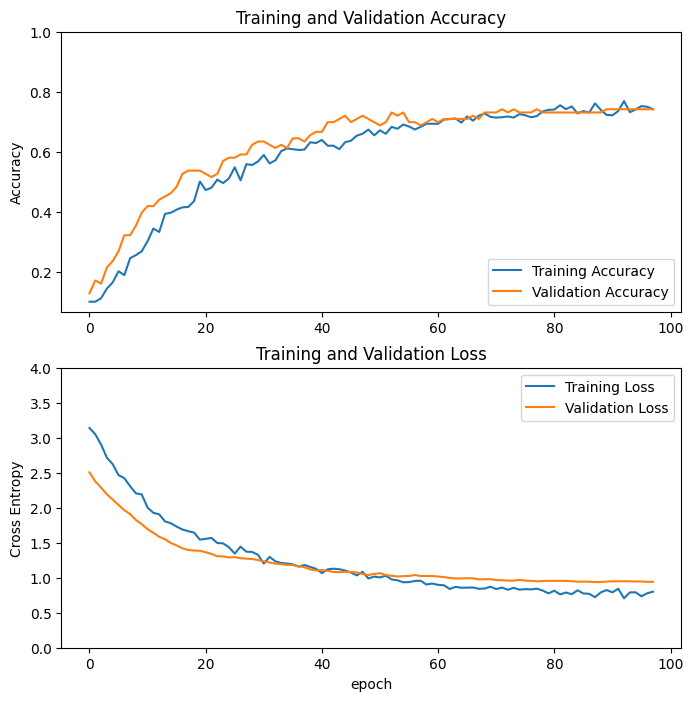

In [16]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,4])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

## Testing Model

Predict skin diseases image via upload file :

In [19]:
uploaded = files.upload()

for fn in uploaded.keys():
  path = '/content/' + fn
  images = image.load_img(path, target_size=(224,224,3))
  images = image.img_to_array(images)
  images = np.expand_dims(images, axis=0)

  classes = model.predict(images/255, batch_size=10)
  predd = np.argsort(-classes)
  print('\n=====================================')
  print('Predictive results of skin diseases :')
  print('=====================================')
  predd = [j for i in predd for j in i][:3]
  disease_names = [
      'Atopic dermatitis', 'Cradle cap', 'Diaper rash', 'Drool rash',
      'HFMD', 'Hemangioma', 'Impetigo', 'Miliaria', 'Pityriasis', 'Rubeola', 'Varicella'
  ]
  for pred in predd:
      prob = classes[0][pred]
      print('{} ({:.2%})'.format(disease_names[pred], prob))

Saving 3.jpg to 3.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step

Predictive results of skin diseases :
Diaper rash (98.71%)
Hemangioma (1.16%)
Cradle cap (0.09%)


## Model Evaluation

In [20]:
test_dir = '/content/skin_dataset/test'

test2_datagen = ImageDataGenerator(rescale=1/255.0)

test_generator = test2_datagen.flow_from_directory(test_dir,
                                                   target_size=(224,224),
                                                   shuffle=False,
                                                   class_mode='categorical')

Found 106 images belonging to 11 classes.


In [21]:
test_labels = test_generator.classes
predictions = model.predict(x=test_generator, verbose=0)

Confusion matrix for testing data :

In [22]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    plt.figure(figsize=(7,7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90, size=10)
    plt.yticks(tick_marks, classes, size=10)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

Confusion matrix, without normalization


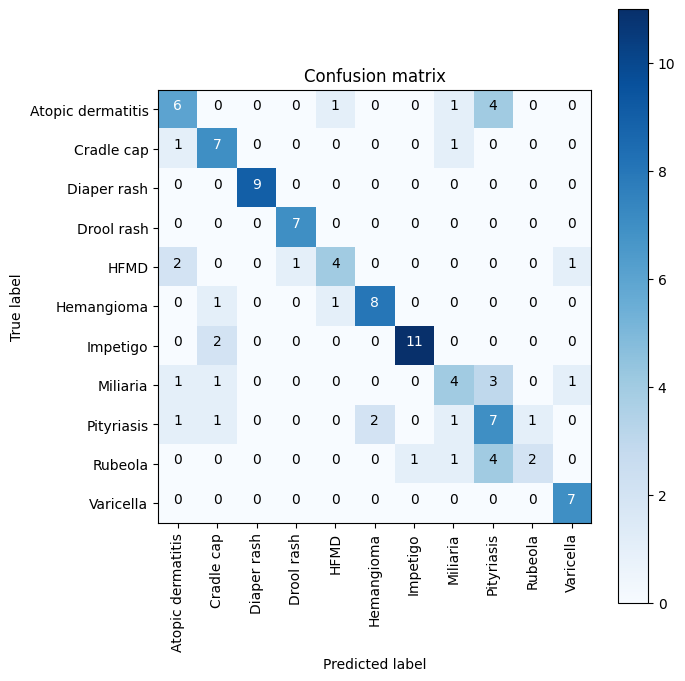

In [23]:
cm = confusion_matrix(y_true=test_labels, y_pred=predictions.argmax(axis=1))
labels = ['Atopic dermatitis', 'Cradle cap', 'Diaper rash','Drool rash','HFMD', 'Hemangioma', 'Impetigo', 'Miliaria', 'Pityriasis', 'Rubeola', 'Varicella']
plot_confusion_matrix(cm, classes=labels)

## Save Model

Save model in format pb :

In [26]:
# ✅ Nouveau
SD_SAVED_MODEL = "skin_diseases.keras"
model.save(SD_SAVED_MODEL)

In [28]:
# ✅ Inspecter le modèle .keras (remplace saved_model_cli)
import keras

loaded_model = keras.models.load_model(SD_SAVED_MODEL)
print("✅ Modèle chargé :", SD_SAVED_MODEL)
print("\n📥 Input  :", loaded_model.input_shape)
print("📤 Output :", loaded_model.output_shape)
loaded_model.summary()

✅ Modèle chargé : skin_diseases.keras

📥 Input  : (None, 224, 224, 3)
📤 Output : (None, 11)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 31 variables whereas the saved optimizer has 60 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 6,541,528 (24.95 MB)

 Trainable params: 2,718,731 (10.37 MB)

 Non-trainable params: 1,104,064 (4.21 MB)

 Optimizer params: 2,718,733 (10.37 MB)

In [30]:
# ✅ Vérifier les signatures (remplace tf.saved_model.load)
print("Nom du modèle :", loaded_model.name)
print("Nombre de couches :", len(loaded_model.layers))
print("Classes de sortie : 11 maladies")

Nom du modèle : functional_1
Nombre de couches : 93
Classes de sortie : 11 maladies


## Convert Model into TF Lite and Post Training Quantization

In [31]:
def representative_data_gen():
  dataset_list = tf.data.Dataset.list_files(test_dir + '/*/*')
  for i in range(99):
    image = next(iter(dataset_list))
    image = tf.io.read_file(image)
    image = tf.io.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (224,224))
    image = tf.cast(image / 255., tf.float32)
    image = tf.expand_dims(image, 0)
    yield [image]

In [32]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()
tflite_model_file = 'converted_model.tflite'

with open(tflite_model_file, "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp06b3z_s5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 11), dtype=tf.float32, name=None)
Captures:
  140323973780432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140323976015184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140323976012688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140323976012304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140323973781584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140323973781776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140323972130064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140323972124496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140323972130448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140323972120848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1403239721216

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [33]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
input_type = interpreter.get_input_details()[0]['dtype']
print('input: ', input_type)
output_type = interpreter.get_output_details()[0]['dtype']
print('output: ', output_type)

input:  <class 'numpy.uint8'>
output:  <class 'numpy.uint8'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## Download Model

Make txt file for skin diseases labels :

In [34]:
with open('labels.txt', 'w') as f:
    f.write('\n'.join(labels))

Download model pb, tflite, and labels :

In [36]:
# ✅ Zipper et télécharger le modèle .keras
!zip -r /content/skin_diseases.zip /content/skin_diseases.keras

files.download('/content/skin_diseases.zip')
files.download('converted_model.tflite')
files.download('labels.txt')

  adding: content/skin_diseases.keras (deflated 9%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>